In [1]:
!pip install -U git+https://github.com/dunderlab/python-dunderlab.visualizations.git

  Cloning https://github.com/dunderlab/python-dunderlab.visualizations.git to /tmp/pip-req-build-g7bl5v_0
  Running command git clone --filter=blob:none --quiet https://github.com/dunderlab/python-dunderlab.visualizations.git /tmp/pip-req-build-g7bl5v_0
  Resolved https://github.com/dunderlab/python-dunderlab.visualizations.git to commit a8057dffbb28ed1c75a4aa45e9713b4a3e0dafe2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 74.8 MB/s eta 0:00:00:00:01
  Created wheel for dunderlab-visualizations: filename=dunderlab_visualizations-0.7-py3-none-any.whl size=24141 sha256=ab83a37b60dc5bc93d71702b972fea2d6160c19c560b3c0123d4857a822c59a9
  Stored in directory: /tmp/pip-ephem-wheel-cache-rr6c2n39/wheels/4a/ac/42/99f48c42e9ace2a78ea76f5ff11306a58d802bac077b3ae3ae
Successfully built dunderlab-visualizations


In [2]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from dunderlab.visualizations.connectivities import CircosConnectivity, interact_connectivity

In [3]:
# ============================================================
# CONECTIVIDAD TE — FOLD 3 / TEST
# Promedio por sujeto y posteriormente por grupo
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. RUTAS
# ============================================================

BASE_DIR = Path(
    "/kaggle/input/datasets/alejandragomezr/"
    "matrices-te-all-folds/"
    "TE_matrices_all_folds_train_validation_test_diag_zero/"
    "fold_3/test"
)

CONTROL_DIR = BASE_DIR / "Control"
TDAH_DIR = BASE_DIR / "TDAH"

assert CONTROL_DIR.exists(), f"No existe: {CONTROL_DIR}"
assert TDAH_DIR.exists(), f"No existe: {TDAH_DIR}"


# ============================================================
# 2. CARGAR UN GRUPO
# ============================================================

def load_te_group(folder, expected_class):
    """
    Cada archivo .npz corresponde a un sujeto y contiene:
        TE_matrices: (n_windows, 19, 19)

    Retorna:
        subject_means: dict sujeto -> matriz media 19x19
        subject_data:  dict sujeto -> metadatos y ventanas
        summary_df:    resumen por sujeto
        channel_names: orden de canales almacenado en los archivos
    """

    files = sorted(folder.glob("*.npz"))

    if not files:
        raise FileNotFoundError(
            f"No se encontraron archivos .npz en {folder}"
        )

    subject_means = {}
    subject_data = {}
    summary_rows = []
    reference_channel_names = None

    for file_path in files:

        with np.load(file_path, allow_pickle=True) as data:

            te = np.asarray(
                data["TE_matrices"],
                dtype=np.float64
            )

            subject_id = str(data["subject_id"].item())
            class_name = str(data["class_name"].item())
            label = int(data["label"].item())
            split = str(data["split"].item())
            fold = int(data["fold"].item())

            channel_names = [
                str(channel)
                for channel in data["channel_names"].tolist()
            ]

            y_window = np.asarray(data["y_window"], dtype=int)
            y_prob = np.asarray(data["y_prob"], dtype=float)
            y_pred = np.asarray(data["y_pred"], dtype=int)
            window_ids = np.asarray(data["window_ids"]).astype(str)

            diagonal_zero = bool(data["diagonal_zero"].item())
            diagonal_removed = bool(data["diagonal_removed"].item())

        # ----------------------------------------------------
        # Validaciones
        # ----------------------------------------------------

        if te.ndim != 3 or te.shape[1:] != (19, 19):
            raise ValueError(
                f"{file_path.name}: forma inesperada {te.shape}"
            )

        if class_name.lower() != expected_class.lower():
            print(
                f"Advertencia: {file_path.name} indica "
                f"class_name={class_name}, esperado={expected_class}"
            )

        if reference_channel_names is None:
            reference_channel_names = channel_names
        elif channel_names != reference_channel_names:
            raise ValueError(
                f"Orden de canales diferente en {file_path.name}"
            )

        if len(y_prob) != te.shape[0]:
            raise ValueError(
                f"{file_path.name}: y_prob y TE_matrices "
                "tienen diferente número de ventanas."
            )

        # Limpiar valores no finitos
        te = np.nan_to_num(
            te,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        # Reforzar diagonal cero
        idx = np.arange(te.shape[1])
        te[:, idx, idx] = 0.0

        # Promedio de todas las ventanas del sujeto
        subject_mean = te.mean(axis=0)

        # Predicción agregada por probabilidad media
        mean_probability = float(y_prob.mean())
        subject_prediction = int(mean_probability >= 0.5)

        # Exactitud por ventanas
        window_accuracy = float((y_pred == y_window).mean())

        subject_means[subject_id] = subject_mean

        subject_data[subject_id] = {
            "TE_matrices": te,
            "mean_TE": subject_mean,
            "label": label,
            "class_name": class_name,
            "split": split,
            "fold": fold,
            "window_ids": window_ids,
            "y_window": y_window,
            "y_prob": y_prob,
            "y_pred": y_pred,
            "mean_probability": mean_probability,
            "subject_prediction": subject_prediction,
            "window_accuracy": window_accuracy,
            "diagonal_zero": diagonal_zero,
            "diagonal_removed": diagonal_removed,
            "file": file_path.name
        }

        summary_rows.append({
            "subject_id": subject_id,
            "class_name": class_name,
            "label": label,
            "n_windows": te.shape[0],
            "mean_probability": mean_probability,
            "subject_prediction": subject_prediction,
            "correct_subject_prediction": (
                subject_prediction == label
            ),
            "window_accuracy": window_accuracy,
            "fold": fold,
            "split": split,
            "file": file_path.name
        })

    summary_df = pd.DataFrame(summary_rows)

    return (
        subject_means,
        subject_data,
        summary_df,
        reference_channel_names
    )


# ============================================================
# 3. CARGAR CONTROL Y TDAH
# ============================================================

(
    control_means,
    control_data,
    control_summary,
    control_channels
) = load_te_group(
    CONTROL_DIR,
    expected_class="Control"
)

(
    tdah_means,
    tdah_data,
    tdah_summary,
    tdah_channels
) = load_te_group(
    TDAH_DIR,
    expected_class="TDAH"
)

assert control_channels == tdah_channels, (
    "El orden de canales difiere entre Control y TDAH."
)

CHANNEL_NAMES = control_channels
N_CHANNELS = len(CHANNEL_NAMES)

print("Orden de canales:")
print(CHANNEL_NAMES)

print("\nSujetos Control:", len(control_means))
print("Sujetos TDAH:", len(tdah_means))


summary_all = pd.concat(
    [control_summary, tdah_summary],
    ignore_index=True
)

display(summary_all.sort_values(
    ["class_name", "subject_id"]
))

Orden de canales:
['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz', 'C3', 'C4', 'Cz', 'P3', 'P4', 'Pz', 'T3', 'T4', 'T5', 'T6', 'O1', 'O2']

Sujetos Control: 12
Sujetos TDAH: 12


,subject_id,class_name,label,n_windows,mean_probability,subject_prediction,correct_subject_prediction,window_accuracy,fold,split,file
0,v113,Control,0,59,0.002961,0,True,1.000000,2,test,v113_TE.npz
1,v120,Control,0,46,0.000132,0,True,1.000000,2,test,v120_TE.npz
2,v140,Control,0,66,0.037496,0,True,0.969697,2,test,v140_TE.npz
3,v147,Control,0,54,0.022758,0,True,0.981481,2,test,v147_TE.npz
4,v297,Control,0,52,0.960905,1,False,0.000000,2,test,v297_TE.npz
5,v299,Control,0,85,0.021124,0,True,0.976471,2,test,v299_TE.npz
6,v300,Control,0,100,0.000293,0,True,1.000000,2,test,v300_TE.npz
7,v303,Control,0,74,0.000402,0,True,1.000000,2,test,v303_TE.npz
8,v306,Control,0,70,0.000006,0,True,1.000000,2,test,v306_TE.npz
9,v310,Control,0,68,0.002906,0,True,1.000000,2,test,v310_TE.npz


In [4]:
# ============================================================
# 4. PROMEDIOS GRUPALES
# ============================================================

control_subject_stack = np.stack(
    list(control_means.values()),
    axis=0
)

tdah_subject_stack = np.stack(
    list(tdah_means.values()),
    axis=0
)

control_group_mean = control_subject_stack.mean(axis=0)
tdah_group_mean = tdah_subject_stack.mean(axis=0)

difference_matrix = (
    tdah_group_mean
    -
    control_group_mean
)

print("Control subject stack:", control_subject_stack.shape)
print("TDAH subject stack   :", tdah_subject_stack.shape)
print("Control group mean   :", control_group_mean.shape)
print("TDAH group mean      :", tdah_group_mean.shape)
print("Difference           :", difference_matrix.shape)

Control subject stack: (12, 19, 19)
TDAH subject stack   : (12, 19, 19)
Control group mean   : (19, 19)
TDAH group mean      : (19, 19)
Difference           : (19, 19)


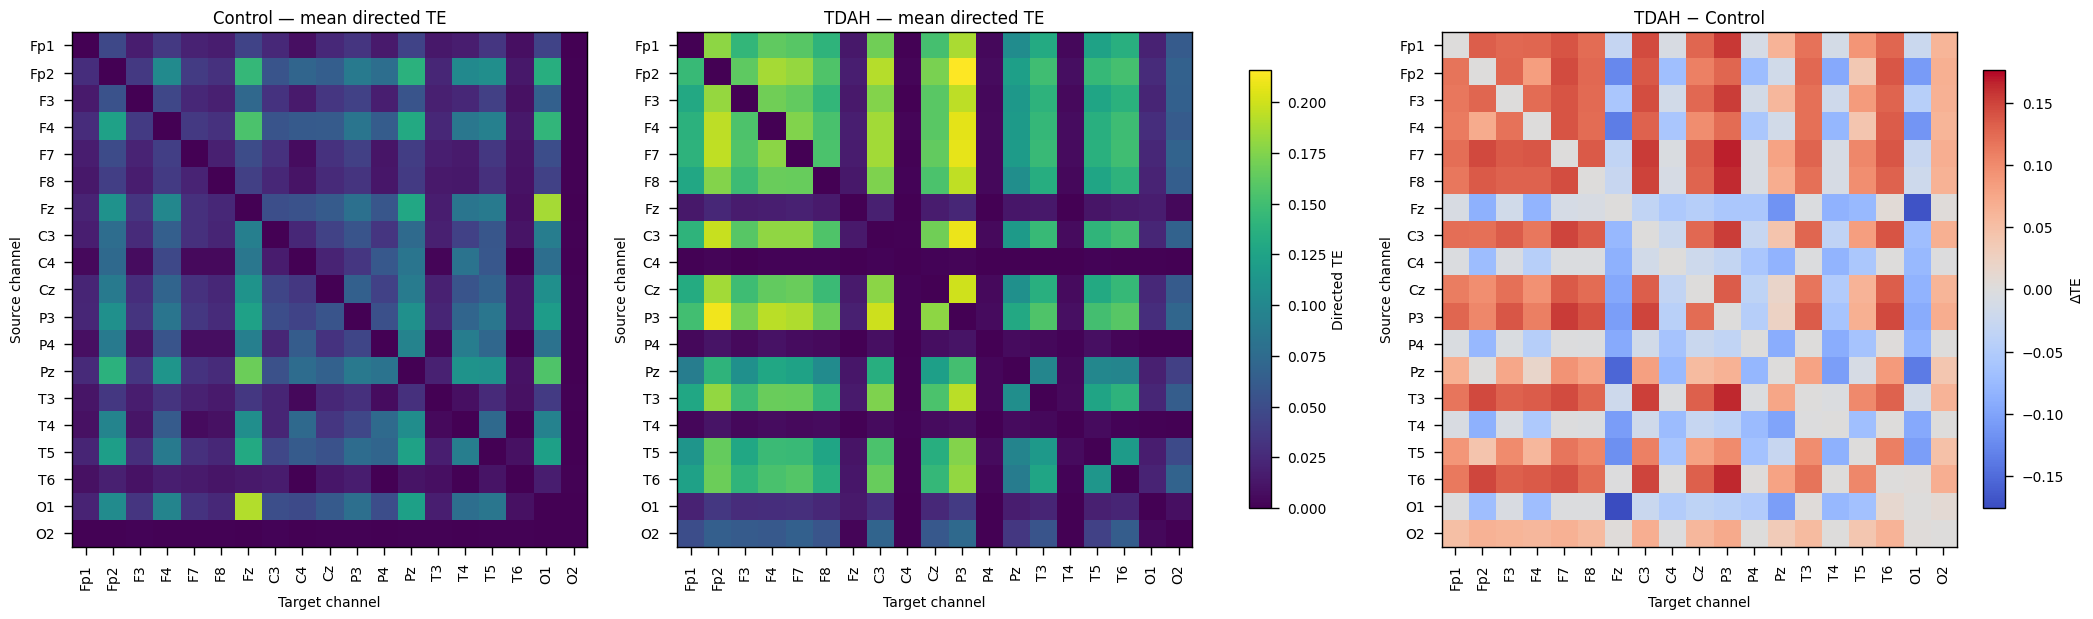

In [5]:
# ============================================================
# 5. MAPAS DE CALOR
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 6),
    constrained_layout=True
)

# Misma escala para Control y TDAH
common_min = min(
    control_group_mean.min(),
    tdah_group_mean.min()
)

common_max = max(
    control_group_mean.max(),
    tdah_group_mean.max()
)

im0 = axes[0].imshow(
    control_group_mean,
    vmin=common_min,
    vmax=common_max,
    aspect="equal"
)

axes[0].set_title(
    "Control — mean directed TE"
)

im1 = axes[1].imshow(
    tdah_group_mean,
    vmin=common_min,
    vmax=common_max,
    aspect="equal"
)

axes[1].set_title(
    "TDAH — mean directed TE"
)

difference_limit = np.max(
    np.abs(difference_matrix)
)

im2 = axes[2].imshow(
    difference_matrix,
    cmap="coolwarm",
    vmin=-difference_limit,
    vmax=difference_limit,
    aspect="equal"
)

axes[2].set_title(
    "TDAH − Control"
)

for axis in axes:
    axis.set_xticks(range(N_CHANNELS))
    axis.set_yticks(range(N_CHANNELS))

    axis.set_xticklabels(
        CHANNEL_NAMES,
        rotation=90
    )

    axis.set_yticklabels(
        CHANNEL_NAMES
    )

    axis.set_xlabel("Target channel")
    axis.set_ylabel("Source channel")

fig.colorbar(
    im0,
    ax=axes[:2],
    shrink=0.85,
    label="Directed TE"
)

fig.colorbar(
    im2,
    ax=axes[2],
    shrink=0.85,
    label="ΔTE"
)

plt.show()

In [6]:
# ============================================================
# 6. SUJETOS BIEN Y MAL CLASIFICADOS
# ============================================================

display(
    summary_all[
        [
            "subject_id",
            "class_name",
            "n_windows",
            "mean_probability",
            "subject_prediction",
            "correct_subject_prediction",
            "window_accuracy"
        ]
    ].sort_values(
        [
            "correct_subject_prediction",
            "class_name",
            "mean_probability"
        ],
        ascending=[True, True, False]
    )
)

,subject_id,class_name,n_windows,mean_probability,subject_prediction,correct_subject_prediction,window_accuracy
4,v297,Control,52,0.960905,1,False,0.000000
19,v27p,TDAH,111,0.276783,0,False,0.270270
10,v47p,Control,41,0.046283,0,True,0.975610
2,v140,Control,66,0.037496,0,True,0.969697
3,v147,Control,54,0.022758,0,True,0.981481
5,v299,Control,85,0.021124,0,True,0.976471
0,v113,Control,59,0.002961,0,True,1.000000
9,v310,Control,68,0.002906,0,True,1.000000
7,v303,Control,74,0.000402,0,True,1.000000
6,v300,Control,100,0.000293,0,True,1.000000


In [7]:
# ============================================================
# SELECCIONAR 4 CASOS REPRESENTATIVOS
# - Mejor Control
# - Mejor TDAH
# - Peor Control
# - Peor TDAH
# ============================================================

# -------------------------------
# CONTROL
# label = 0
# mejor: menor probabilidad de TDAH
# peor: mayor probabilidad de TDAH
# -------------------------------

best_control_row = control_summary.sort_values(
    "mean_probability",
    ascending=True
).iloc[0]

worst_control_row = control_summary.sort_values(
    "mean_probability",
    ascending=False
).iloc[0]


# -------------------------------
# TDAH
# label = 1
# mejor: mayor probabilidad de TDAH
# peor: menor probabilidad de TDAH
# -------------------------------

best_tdah_row = tdah_summary.sort_values(
    "mean_probability",
    ascending=False
).iloc[0]

worst_tdah_row = tdah_summary.sort_values(
    "mean_probability",
    ascending=True
).iloc[0]


# IDs de sujetos
best_control_id = best_control_row["subject_id"]
worst_control_id = worst_control_row["subject_id"]

best_tdah_id = best_tdah_row["subject_id"]
worst_tdah_id = worst_tdah_row["subject_id"]


# Matrices TE promedio por sujeto
selected_subjects = {
    f"Best Control — {best_control_id}": control_means[best_control_id],
    f"Best TDAH — {best_tdah_id}": tdah_means[best_tdah_id],
    f"Worst Control — {worst_control_id}": control_means[worst_control_id],
    f"Worst TDAH — {worst_tdah_id}": tdah_means[worst_tdah_id],
}


# Tabla resumen
selected_summary = pd.DataFrame([
    {
        "case": "Best Control",
        "subject_id": best_control_id,
        "true_class": "Control",
        "mean_probability_TDAH": best_control_row["mean_probability"],
        "subject_prediction": best_control_row["subject_prediction"],
        "correct": best_control_row["correct_subject_prediction"],
        "window_accuracy": best_control_row["window_accuracy"],
        "n_windows": best_control_row["n_windows"],
    },
    {
        "case": "Best TDAH",
        "subject_id": best_tdah_id,
        "true_class": "TDAH",
        "mean_probability_TDAH": best_tdah_row["mean_probability"],
        "subject_prediction": best_tdah_row["subject_prediction"],
        "correct": best_tdah_row["correct_subject_prediction"],
        "window_accuracy": best_tdah_row["window_accuracy"],
        "n_windows": best_tdah_row["n_windows"],
    },
    {
        "case": "Worst Control",
        "subject_id": worst_control_id,
        "true_class": "Control",
        "mean_probability_TDAH": worst_control_row["mean_probability"],
        "subject_prediction": worst_control_row["subject_prediction"],
        "correct": worst_control_row["correct_subject_prediction"],
        "window_accuracy": worst_control_row["window_accuracy"],
        "n_windows": worst_control_row["n_windows"],
    },
    {
        "case": "Worst TDAH",
        "subject_id": worst_tdah_id,
        "true_class": "TDAH",
        "mean_probability_TDAH": worst_tdah_row["mean_probability"],
        "subject_prediction": worst_tdah_row["subject_prediction"],
        "correct": worst_tdah_row["correct_subject_prediction"],
        "window_accuracy": worst_tdah_row["window_accuracy"],
        "n_windows": worst_tdah_row["n_windows"],
    },
])

display(selected_summary)

,case,subject_id,true_class,mean_probability_TDAH,subject_prediction,correct,window_accuracy,n_windows
0,Best Control,v306,Control,0.000006,0,True,1.00000,70
1,Best TDAH,v284,TDAH,0.999855,1,True,1.00000,59
2,Worst Control,v297,Control,0.960905,1,False,0.00000,52
3,Worst TDAH,v27p,TDAH,0.276783,0,False,0.27027,111


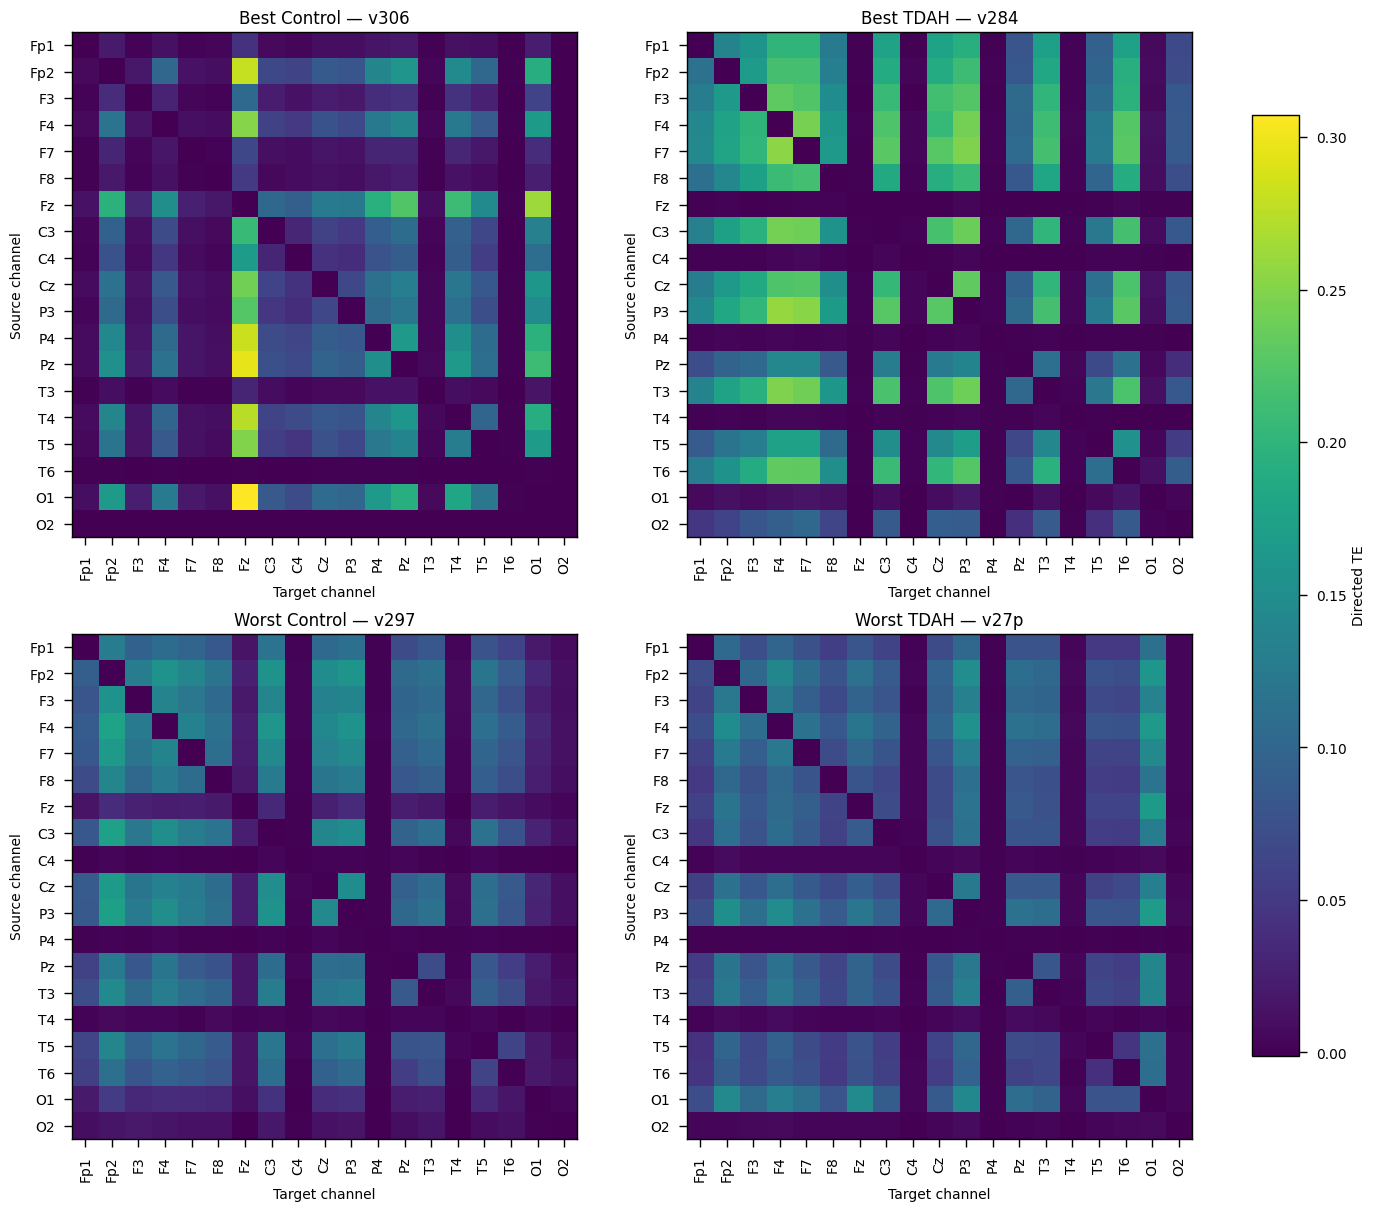

In [8]:
# ============================================================
# GRAFICAR LOS 4 CASOS
# ============================================================

all_selected_matrices = list(selected_subjects.values())

common_min = min(matrix.min() for matrix in all_selected_matrices)
common_max = max(matrix.max() for matrix in all_selected_matrices)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 12),
    constrained_layout=True
)

axes = axes.ravel()

for ax, (title, matrix) in zip(axes, selected_subjects.items()):

    im = ax.imshow(
        matrix,
        vmin=common_min,
        vmax=common_max,
        aspect="equal"
    )

    ax.set_title(title)

    ax.set_xticks(range(N_CHANNELS))
    ax.set_yticks(range(N_CHANNELS))

    ax.set_xticklabels(
        CHANNEL_NAMES,
        rotation=90
    )

    ax.set_yticklabels(
        CHANNEL_NAMES
    )

    ax.set_xlabel("Target channel")
    ax.set_ylabel("Source channel")

fig.colorbar(
    im,
    ax=axes,
    shrink=0.85,
    label="Directed TE"
)

plt.show()

In [9]:
summary_all["true_class_confidence"] = np.where(
    summary_all["label"] == 1,
    summary_all["mean_probability"],
    1.0 - summary_all["mean_probability"]
)

display(
    summary_all[
        [
            "subject_id",
            "class_name",
            "mean_probability",
            "true_class_confidence",
            "subject_prediction",
            "correct_subject_prediction",
            "window_accuracy"
        ]
    ].sort_values(
        "true_class_confidence",
        ascending=False
    )
)

,subject_id,class_name,mean_probability,true_class_confidence,subject_prediction,correct_subject_prediction,window_accuracy
8,v306,Control,0.000006,0.999994,0,True,1.000000
1,v120,Control,0.000132,0.999868,0,True,1.000000
20,v284,TDAH,0.999855,0.999855,1,True,1.000000
11,v58p,Control,0.000166,0.999834,0,True,1.000000
6,v300,Control,0.000293,0.999707,0,True,1.000000
15,v213,TDAH,0.999614,0.999614,1,True,1.000000
7,v303,Control,0.000402,0.999598,0,True,1.000000
22,v35p,TDAH,0.999282,0.999282,1,True,1.000000
12,v179,TDAH,0.998903,0.998903,1,True,1.000000
9,v310,Control,0.002906,0.997094,0,True,1.000000


In [16]:
areas = {
    'Frontal': ['Fz'],

    'Frontal Right': ['Fp2', 'F4', 'F8'],
    'Central R': ['C4'],
    'Posterior Right': ['P4', 'O2'],

    'Posterior': ['Pz', 'Cz'],

    'Posterior Left': ['O1', 'P3'],
    'Central L ': ['C3'],
    'Frontal Left': ['Fp1', 'F3', 'F7'],

    'Temporal Left': ['T3', 'T5'],
    'Temporal Right': ['T4', 'T6'],
}

In [17]:
channels = [
    'Fz',

    'Fp2', 'F4', 'F8',
    'C4',
    'P4', 'O2',

    'Pz', 'Cz',

    'O1', 'P3',
    'C3',
    'Fp1', 'F3', 'F7',

    'T3', 'T5',
    'T4', 'T6',
]

In [28]:
import numpy as np

# ============================================================
# 1. CARGAR LAS MATRICES DE LOS DOS SUJETOS
# ============================================================

promedio_control = control_means["v306"].copy()
promedio_tdah = tdah_means["v284"].copy()


# ============================================================
# 2. CALCULAR RANGO GLOBAL COMPARTIDO
# ============================================================

global_min = min(
    promedio_control.min(),
    promedio_tdah.min()
)

global_max = max(
    promedio_control.max(),
    promedio_tdah.max()
)

print("Mínimo global:", global_min)
print("Máximo global:", global_max)


# ============================================================
# 3. NORMALIZAR AMBAS MATRICES CON EL MISMO RANGO
# ============================================================

def normalize_shared_range(matrix, global_min, global_max):
    normalized = (
        matrix - global_min
    ) / (
        global_max - global_min + 1e-12
    )

    normalized = np.clip(
        normalized,
        0.0,
        1.0
    )

    np.fill_diagonal(
        normalized,
        0.0
    )

    return normalized


promedio_control_norm = normalize_shared_range(
    promedio_control,
    global_min,
    global_max
)

promedio_tdah_norm = normalize_shared_range(
    promedio_tdah,
    global_min,
    global_max
)


print(
    "Control normalizado:",
    promedio_control_norm.min(),
    promedio_control_norm.max()
)

print(
    "TDAH normalizado:",
    promedio_tdah_norm.min(),
    promedio_tdah_norm.max()
)

Mínimo global: -0.0007275888800891789
Máximo global: 0.3073733925819397
Control normalizado: 0.0 0.9999999999967544
TDAH normalizado: 0.0 0.8403476934612901


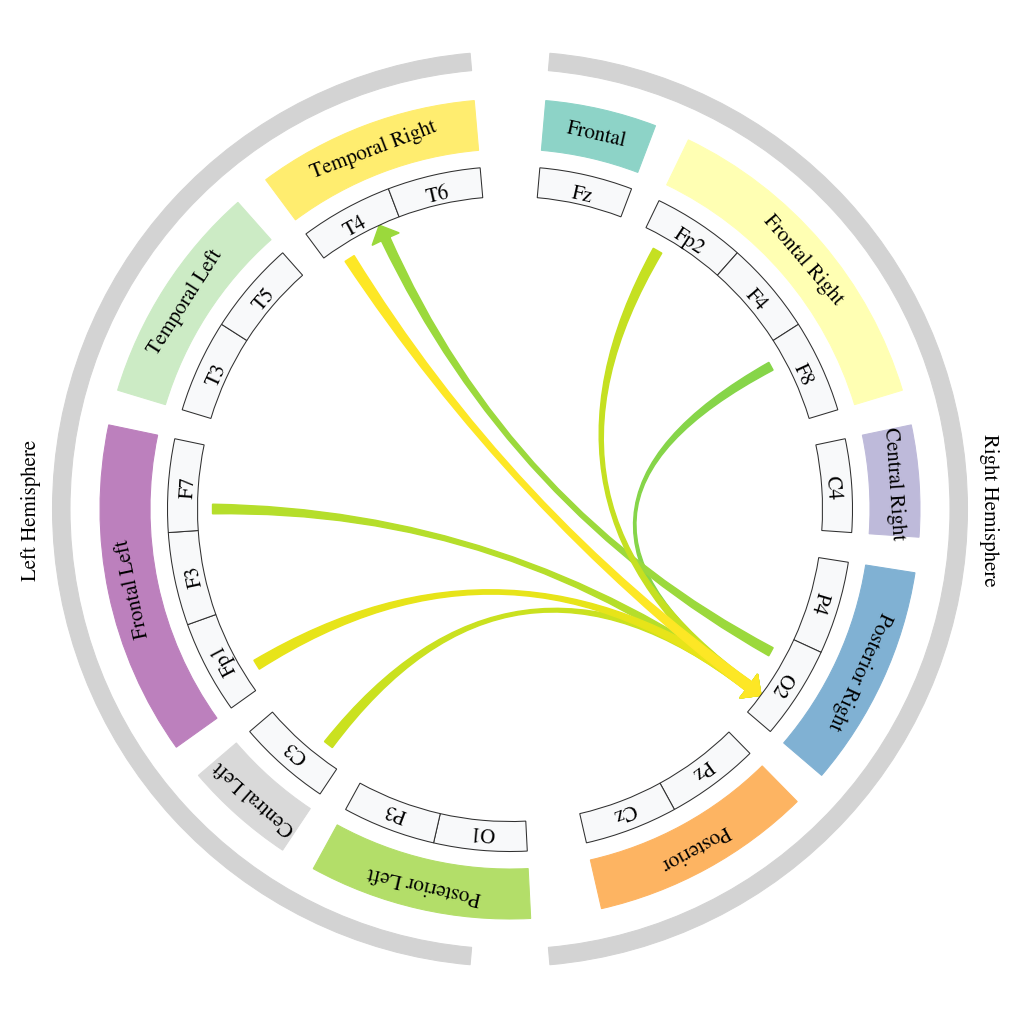

In [44]:
arguments_control = arguments.copy()

arguments_control.update({
    'threshold': 0.1,
    'percentile': [95, 100],
    'arcs_cmap': 'viridis',
    'normalize_colors': False,
})

CircosConnectivity(
    promedio_control_norm,
    channels,
    areas,
    **arguments_control
)
fig = plt.gcf()

fig.savefig(
    "best_control_v306_normalized.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

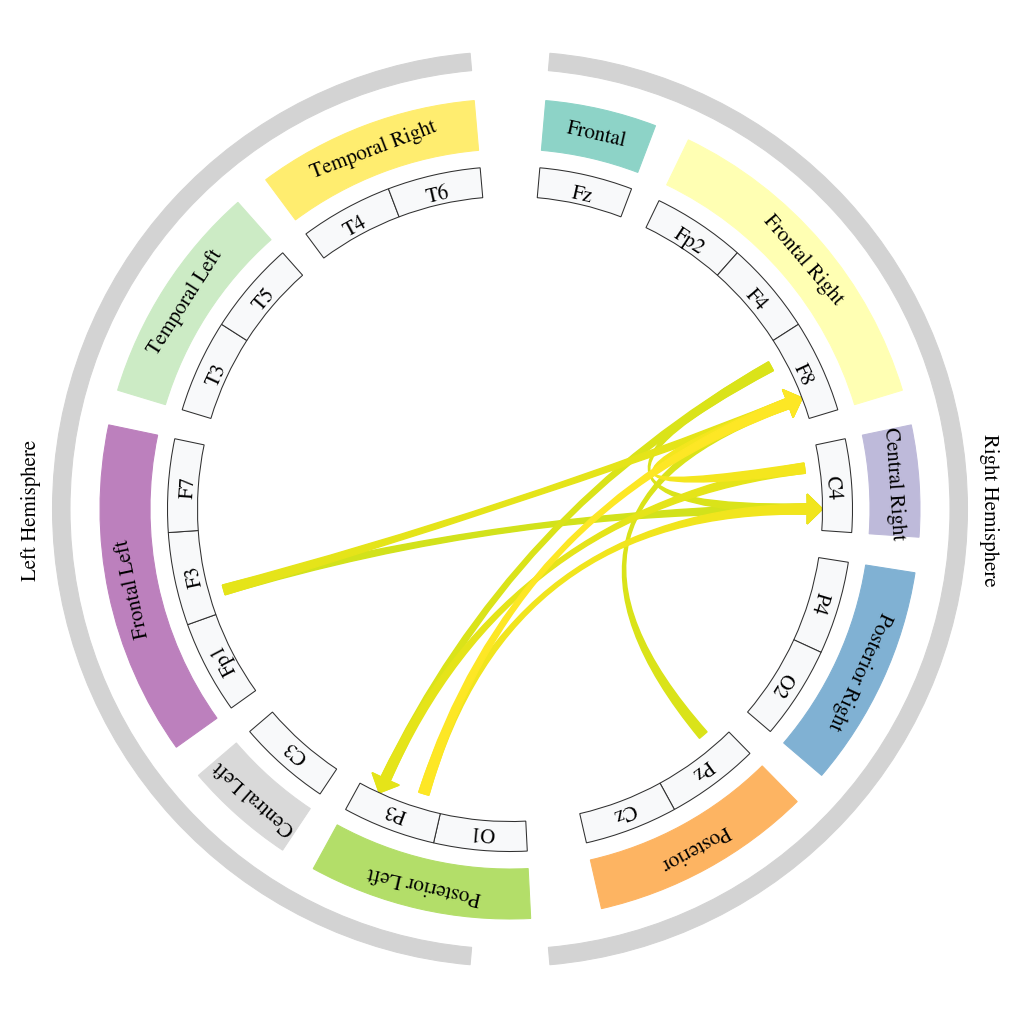

In [40]:
arguments_tdah = arguments.copy()

arguments_tdah.update({
    'threshold': 0.1,
    'percentile': [95, 100],
    'arcs_cmap': 'viridis',
    'normalize_colors': False,
})

CircosConnectivity(
    promedio_tdah_norm,
    channels,
    areas,
    **arguments_tdah
)
fig = plt.gcf()

fig.savefig(
    "best_tdah_v284_normalized.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. MATRICES DE LOS SUJETOS MAL CLASIFICADOS
# ============================================================

promedio_control_mal = control_means["v297"].copy()
promedio_tdah_mal = tdah_means["v27p"].copy()


# ============================================================
# 2. RANGO GLOBAL COMPARTIDO
# ============================================================

global_min_mal = min(
    promedio_control_mal.min(),
    promedio_tdah_mal.min()
)

global_max_mal = max(
    promedio_control_mal.max(),
    promedio_tdah_mal.max()
)

print("Mínimo global:", global_min_mal)
print("Máximo global:", global_max_mal)


# ============================================================
# 3. NORMALIZACIÓN COMPARTIDA
# ============================================================

def normalize_shared_range(matrix, global_min, global_max):
    normalized = (
        matrix - global_min
    ) / (
        global_max - global_min + 1e-12
    )

    normalized = np.clip(
        normalized,
        0.0,
        1.0
    )

    np.fill_diagonal(
        normalized,
        0.0
    )

    return normalized


promedio_control_mal_norm = normalize_shared_range(
    promedio_control_mal,
    global_min_mal,
    global_max_mal
)

promedio_tdah_mal_norm = normalize_shared_range(
    promedio_tdah_mal,
    global_min_mal,
    global_max_mal
)

print(
    "Control mal clasificado:",
    promedio_control_mal_norm.min(),
    promedio_control_mal_norm.max()
)

print(
    "TDAH mal clasificado:",
    promedio_tdah_mal_norm.min(),
    promedio_tdah_mal_norm.max()
)

Mínimo global: -0.0011587995825069496
Máximo global: 0.17764138143796188
Control mal clasificado: 0.0 0.9999999999944071
TDAH mal clasificado: 0.0 0.9495843913541769


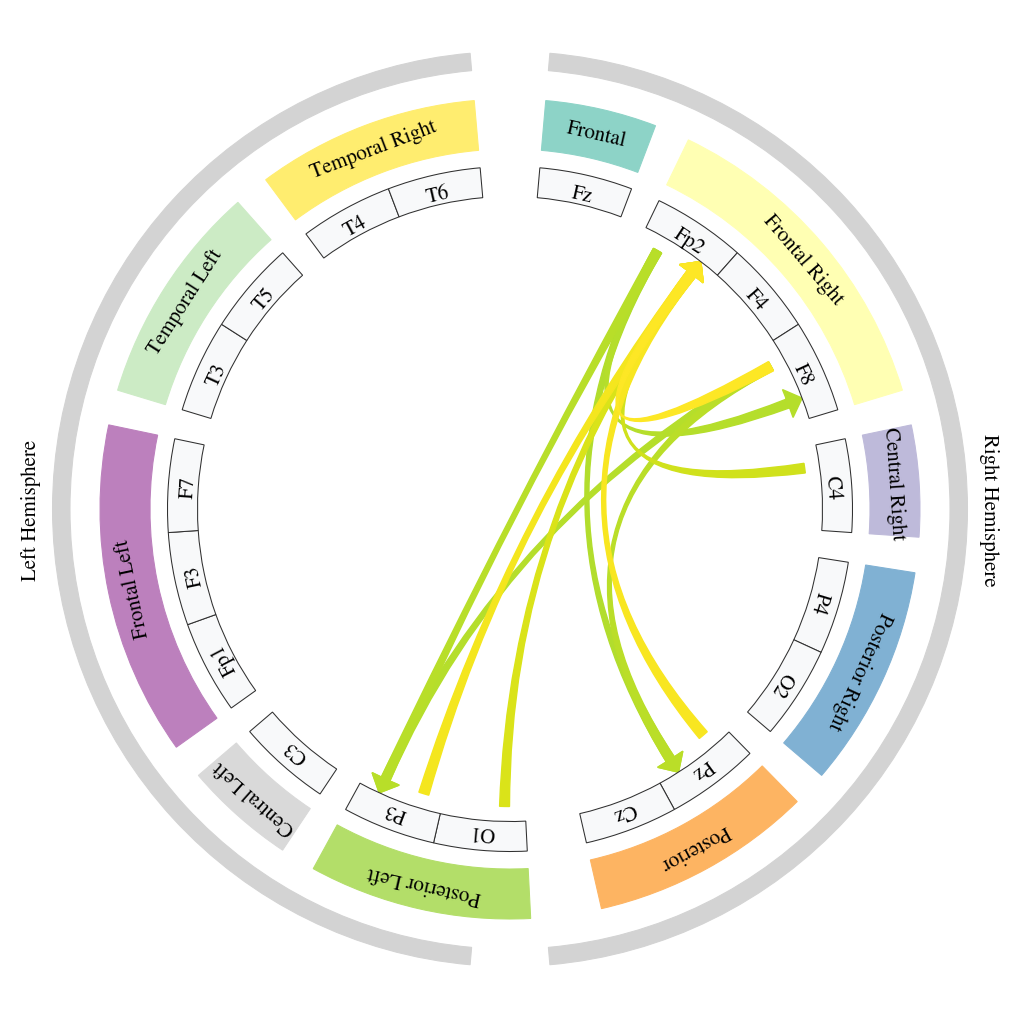

In [46]:
arguments_control_mal = arguments.copy()

arguments_control_mal.update({
    'threshold': 0.1,
    'percentile': [95, 100],
    'arcs_cmap': 'viridis',
    'normalize_colors': False,
})

CircosConnectivity(
    promedio_control_mal_norm,
    channels,
    areas,
    **arguments_control_mal
)

fig = plt.gcf()

fig.savefig(
    "misclassified_control_v297_normalized.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

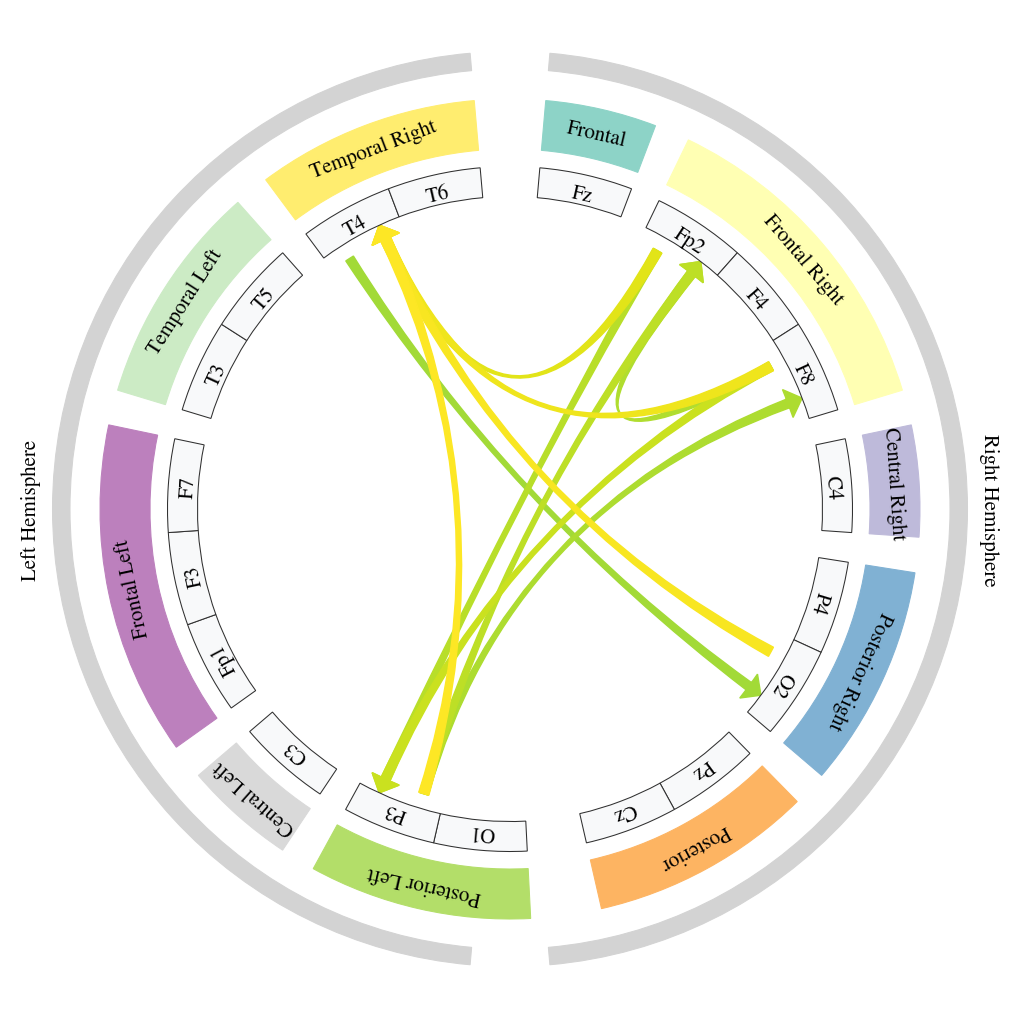

In [47]:
arguments_tdah_mal = arguments.copy()

arguments_tdah_mal.update({
    'threshold': 0.1,
    'percentile': [95, 100],
    'arcs_cmap': 'viridis',
    'normalize_colors': False,
})

CircosConnectivity(
    promedio_tdah_mal_norm,
    channels,
    areas,
    **arguments_tdah_mal
)

fig = plt.gcf()

fig.savefig(
    "misclassified_tdah_v27p_normalized.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()